<a href="https://colab.research.google.com/github/rajan314/Overfitting_and-_Underfitting-supply-chain-Analysis-/blob/main/ovrftunderft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


Step 1: Load Data

In [2]:
def load_data():
    # Sample synthetic dataset for demonstration
    np.random.seed(42)
    data = {
        'date': pd.date_range(start='2022-01-01', periods=365, freq='D'),
        'demand': np.random.poisson(lam=50, size=365) + np.sin(np.linspace(0, 2 * np.pi, 365)) * 10,

        'stock_level': np.random.randint(20, 100, size=365),
        'supplier_lead_time': np.random.randint(2, 10, size=365)
    }
    df = pd.DataFrame(data)
    return df

Step 2: Feature Engineering

In [3]:
def feature_engineering(df):
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['rolling_demand'] = df['demand'].rolling(window=7, min_periods=1).mean()
    df.drop(columns=['date'], inplace=True)  # Drop date for ML models
    return df

Step 3: Train-Test Split

In [4]:
def split_data(df):
    X = df.drop(columns=['demand'])
    y = df['demand']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test


Step 4: Train Model

In [5]:
def train_model(X_train, y_train):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

Step 5: Evaluate Model

In [6]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Square Error (RMSE): {rmse:.2f}")
    return predictions


 Step 6: Visualization

In [7]:
def visualize_results(y_test, predictions):
    plt.figure(figsize=(10, 6))
    plt.plot(y_test.values, label='Actual Demand', alpha=0.7)
    plt.plot(predictions, label='Predicted Demand', alpha=0.7)
    plt.legend()
    plt.title("Actual vs Predicted Demand")
    plt.xlabel("Samples")
    plt.ylabel("Demand")
    plt.show()


Main Program

Loading data...
Performing feature engineering...
Splitting data...
Training model...
Evaluating model...
Mean Absolute Error (MAE): 6.27
Root Mean Square Error (RMSE): 7.98
Visualizing results...


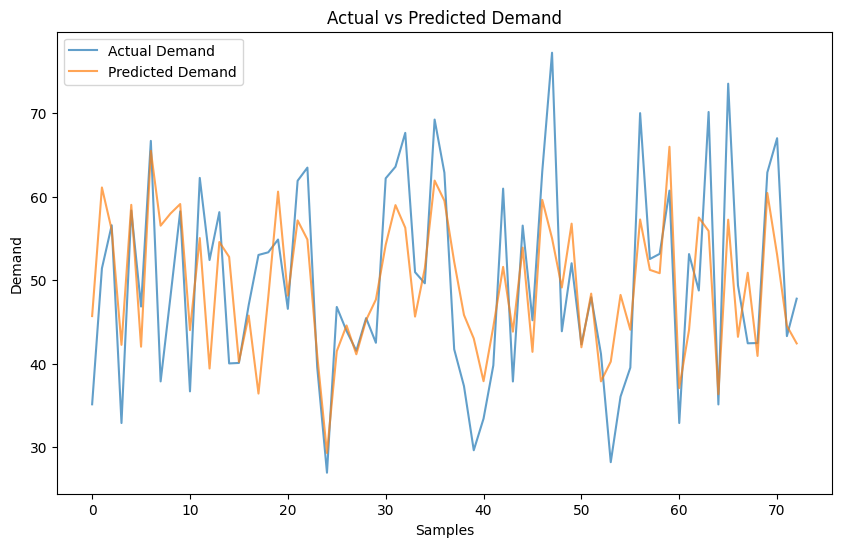

In [8]:
def main():
    print("Loading data...")
    df = load_data()
    print("Performing feature engineering...")
    df = feature_engineering(df)
    print("Splitting data...")
    X_train, X_test, y_train, y_test = split_data(df)
    print("Training model...")
    model = train_model(X_train, y_train)
    print("Evaluating model...")
    predictions = evaluate_model(model, X_test, y_test)
    print("Visualizing results...")
    visualize_results(y_test, predictions)

if __name__ == "__main__":
    main()